# Gaussian Smoothing With a Custom Hexagonal 2D Kernel

Port of HexagDLy's own `hexagdly_custom_kernels_example.ipynb`. Just like upstream's `Conv2d_CustomKernel`, `keras_hexagdly.Conv2d_CustomKernel` lets you fill every element of a hexagonal kernel with an arbitrary value -- useful for manual pre-processing of hexagonally sampled data. The example below builds a Gaussian smoothing kernel of size 2, using the exact same per-cell pixel coordinates as the original (the hexagonal lattice geometry doesn't change between frameworks).

In [1]:
%matplotlib inline
import numpy as np
import keras
import keras_hexagdly as hgly


def gauss(x, y, s=1):
    return np.exp(-0.5 * (x / s) ** 2) * np.exp(-0.5 * (y / s) ** 2)


def gauss_smoothing_sub_kernels(sigma):
    """vertical & horizontal distance between pixels of a hexagonal lattice
    in Cartesian coordinates"""
    ystep, xstep = np.sqrt(3), 1.5

    # x- & y- pixel coordinates for a kernel of size 2
    # sub-kernel no. 0, central column of length (2 * kernel size + 1 - 0)
    kernelx_0 = xstep * np.array([[0], [0], [0], [0], [0]])[np.newaxis, np.newaxis]
    kernely_0 = ystep * np.array([[2], [1], [0], [-1], [-2]])

    # sub-kernel no. 1, first neighbour columns of length (2 * kernel size + 1 - 1)
    kernelx_1 = xstep * np.array([[-1, 1], [-1, 1], [-1, 1], [-1, 1]])[np.newaxis, np.newaxis]
    kernely_1 = ystep * np.array([[1.5, 1.5], [.5, .5], [-.5, -.5], [-1.5, -1.5]])[np.newaxis, np.newaxis]

    # sub-kernel no. 2, second neighbour columns of length (2 * kernel size + 1 - 2)
    kernelx_2 = xstep * np.array([[-2, 2], [-2, 2], [-2, 2]])[np.newaxis, np.newaxis]
    kernely_2 = ystep * np.array([[1, 1], [0, 0], [-1, -1]])[np.newaxis, np.newaxis]

    # pixel values for the kernel from a Gauss distribution
    sub_kernels = [
        gauss(kernelx_0, kernely_0, sigma),   # central column
        gauss(kernelx_1, kernely_1, sigma),   # 1st neighbour columns
        gauss(kernelx_2, kernely_2, sigma),   # 2nd neighbour columns
    ]

    # normalise so the kernel sums to 1 (preserves total intensity)
    w = sum(x.sum() for x in sub_kernels)
    w = 1 if w == 0 else w
    return [x / w for x in sub_kernels]

`sub_kernels` is already in the `(out, in, rows, cols)` layout `Conv2d_CustomKernel` expects (the same as upstream HexagDLy -- it is transposed to channels-last internally), so building the layer is one line:

In [2]:
sigma = 1  # standard deviation for Gaussian smoothing
smoothing_kernel = hgly.Conv2d_CustomKernel(sub_kernels=gauss_smoothing_sub_kernels(sigma))

Next, a hexagonally sampled hexagonal shape is created with the toy-data utilities, then smoothed with the constructed kernel:

total intensity before: 13.0  after: 12.999999


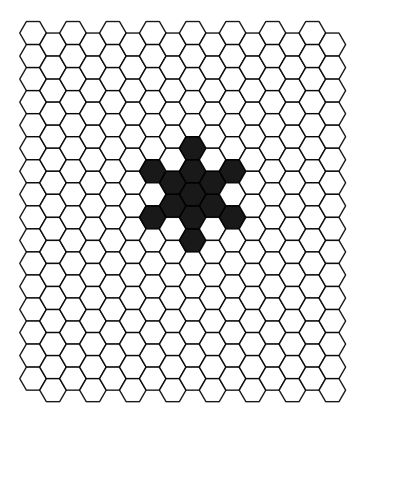

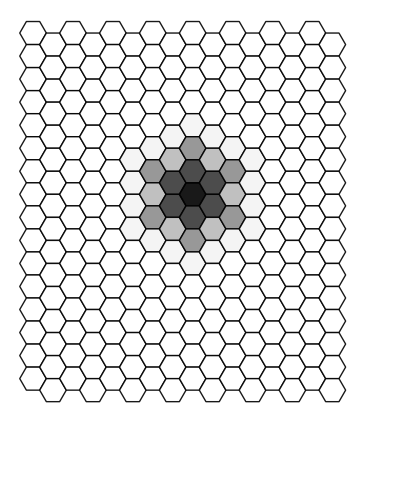

In [3]:
from toy_data import toy_hex_image
from hexplot import plot_hextensor

num_rows, num_columns, channels = 16, 16, 1
testimage = toy_hex_image('snowflake_2', num_rows, num_columns, channels, px=8, py=7)
plot_hextensor(testimage, figname='test_image')

smoothedimage = keras.ops.convert_to_numpy(smoothing_kernel(keras.ops.convert_to_tensor(testimage)))
plot_hextensor(smoothedimage, figname='smoothed_image')

print('total intensity before:', testimage.sum(), ' after:', smoothedimage.sum())